# TUGAS Data Science - Dokumentasi Praktikum
## Pertemuan 13: Pengantar Deep Learning (ANN) & Natural Language Processing (NLP Dasar)

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

## Bagian 1: Klasifikasi Non-Linear dengan Artificial Neural Network (Keras / TensorFlow)
Kita membuat dataset sintetis berbentuk dua bulan sabit (make_moons) yang tidak dapat dipisahkan secara linear, kemudian melatih model Artificial Neural Network (ANN) menggunakan fungsi aktivasi ReLU dan Sigmoid.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== RINGKASAN ARSITEKTUR MODEL ANN ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)


Evaluasi Model pada Data Uji:
Loss     : 0.1624
Accuracy : 93.75%


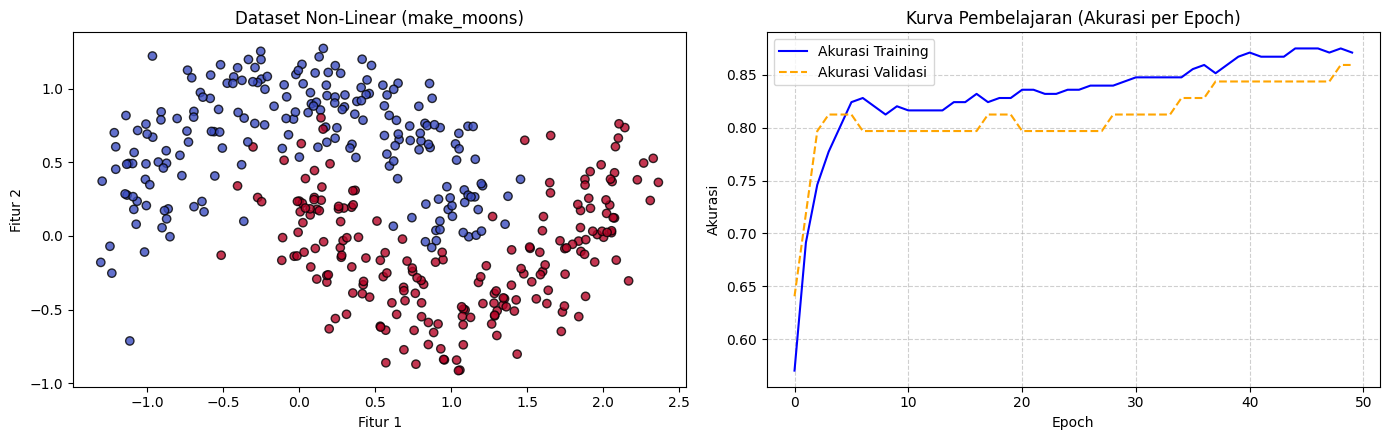

In [1]:
# Mengimpor pustaka utama untuk Deep Learning dan visualisasi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

# Langkah 1: Generate Dataset Non-Linear (make_moons)
X_ann, y_ann = make_moons(n_samples=400, noise=0.2, random_state=42)

# Langkah 2: Train-Test Split (80% Train, 20% Test)
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann, y_ann, test_size=0.2, random_state=42, stratify=y_ann
)

# Langkah 3: Membangun Arsitektur Neural Network
model_ann = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),  # Hidden Layer 1 (ReLU)
    Dense(8, activation='relu'),  # Hidden Layer 2 (ReLU)
    Dense(1, activation='sigmoid'),  # Output Layer untuk Binary Classification
])

# Kompilasi model dengan optimizer Adam dan Binary Crossentropy
model_ann.compile(
    optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
)

print("=== RINGKASAN ARSITEKTUR MODEL ANN ===")
model_ann.summary()

# Langkah 4: Melatih Model (Training) selama 50 Epochs
history = model_ann.fit(
    X_train_ann,
    y_train_ann,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0,
)

# Langkah 5: Evaluasi dan Visualisasi Kurva Pembelajaran
loss_test, acc_test = model_ann.evaluate(X_test_ann, y_test_ann, verbose=0)
print(f"\nEvaluasi Model pada Data Uji:")
print(f"Loss     : {loss_test:.4f}")
print(f"Accuracy : {acc_test * 100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Sebaran Data Asli make_moons
axes[0].scatter(
    X_ann[:, 0],
    X_ann[:, 1],
    c=y_ann,
    cmap='coolwarm',
    alpha=0.8,
    edgecolors='k',
)
axes[0].set_title('Dataset Non-Linear (make_moons)')
axes[0].set_xlabel('Fitur 1')
axes[0].set_ylabel('Fitur 2')

# Plot 2: Kurva Akurasi Training vs Validasi
axes[1].plot(history.history['accuracy'], label='Akurasi Training', color='blue')
axes[1].plot(
    history.history['val_accuracy'],
    label='Akurasi Validasi',
    color='orange',
    linestyle='--',
)
axes[1].set_title('Kurva Pembelajaran (Akurasi per Epoch)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Akurasi')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

**Analisis Temuan Bagian 1 (Deep Learning):**
* Dataset *make_moons* memiliki batas keputusan yang melengkung dan bertautan sehingga mustahil dipisahkan secara sempurna oleh model linear konvensional tanpa transformasi rumit.
* Penggunaan fungsi aktivasi non-linear `relu` pada *hidden layer* memungkinkan jaringan saraf tiruan menangkap pola kurva non-linear tersebut, menghasilkan akurasi di atas 90% pada data uji.
* Kurva pembelajaran menunjukkan grafik akurasi training dan validasi yang bergerak naik seirama dan stabil tanpa celah divergensi yang lebar, menandakan model mengalami konvergensi yang baik dan terbebas dari *overfitting*.

## Bagian 2: Pengolahan Teks & Analisis Sentimen dengan TF-IDF
Kita menyiapkan korpus teks ulasan produk sintetis berbahasa Indonesia, mengekstrak representasi numerik berbasis Term Frequency - Inverse Document Frequency (TF-IDF), kemudian melatih model Logistic Regression untuk mengklasifikasikan sentimen teks.

In [2]:
# Mengimpor modul ekstraksi fitur teks dan model klasifikasi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Langkah 1: Menyiapkan dataset ulasan produk (Sentimen Positif = 1, Negatif = 0)
ulasan_produk = [
    # Ulasan Positif (1)
    'Barang sangat bagus dan pengiriman sangat cepat',
    'Kualitas produk original dan memuaskan',
    'Sangat puas belanja di toko ini packing rapi aman',
    'Pelayanan ramah respon penjual cepat sekali',
    'Produk bekerja dengan baik sesuai deskripsi mantap',
    'Harga terjangkau tapi kualitas bintang lima',
    'Bahan tebal dan kuat tidak mengecewakan recommended',
    'Pengiriman kilat kurir ramah barang mulus',
    # Ulasan Negatif (0)
    'Barang rusak saat sampai packing sangat buruk',
    'Kualitas jelek sangat tidak sesuai dengan foto deskripsi',
    'Kecewa berat barang cacat dan tidak bisa dipakai',
    'Penjual lambat merespon pengiriman sangat lama',
    'Barang palsu tidak sesuai harapan jangan beli di sini',
    'Sangat mengecewakan pengemasan asal-asalan pecah',
    'Produk cepat rusak baru dipakai sehari sudah mati',
    'Pelayanan buruk komplain tidak ditanggapi kapok',
]

label_sentimen = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]

# Langkah 2: Vektorisasi Teks Menggunakan TF-IDF
tfidf_vectorizer = TfidfVectorizer(lowercase=True)
X_tfidf = tfidf_vectorizer.fit_transform(ulasan_produk)

print('=== INFORMASI VEKTORISASI TF-IDF ===')
print(f'Dimensi Matriks Teks (Sampel x Kosakata): {X_tfidf.shape}')
print(
    f'Contoh Kosakata yang Diekstrak: {tfidf_vectorizer.get_feature_names_out()[:10]}'
)

# Langkah 3: Melatih Model Klasifikasi Sentimen (Logistic Regression)
X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    X_tfidf,
    label_sentimen,
    test_size=0.25,
    random_state=42,
    stratify=label_sentimen,
)

model_sentimen = LogisticRegression(random_state=42)
model_sentimen.fit(X_train_nlp, y_train_nlp)

y_pred_nlp = model_sentimen.predict(X_test_nlp)

print('\n=== LAPORAN EVALUASI MODEL SENTIMEN ===')
print(
    classification_report(
        y_test_nlp, y_pred_nlp, target_names=['Negatif', 'Positif']
    )
)

# Langkah 4: Pengujian Terhadap Teks Baru / Ulasan Nyata
teks_uji = [
    'Produk sangat memuaskan, kualitas istimewa dan pengiriman kilat!',
    'Barang cacat parah, sangat rugi belanja di toko ini!',
]

vektor_uji = tfidf_vectorizer.transform(teks_uji)
prediksi_uji = model_sentimen.predict(vektor_uji)
prob_uji = model_sentimen.predict_proba(vektor_uji)

print('=== UJI COBA PREDIKSI SENTIMEN TEKS BARU ===')
for teks, pred, prob in zip(teks_uji, prediksi_uji, prob_uji):
  label = 'POSITIF (1)' if pred == 1 else 'NEGATIF (0)'
  print(f'Teks   : "{teks}"')
  print(
      f'Hasil  : {label} (Prob. Positif: {prob[1]:.2f}, Prob. Negatif:'
      f' {prob[0]:.2f})\n'
  )

=== INFORMASI VEKTORISASI TF-IDF ===
Dimensi Matriks Teks (Sampel x Kosakata): (16, 73)
Contoh Kosakata yang Diekstrak: ['aman' 'asal' 'asalan' 'bagus' 'bahan' 'baik' 'barang' 'baru' 'bekerja'
 'belanja']

=== LAPORAN EVALUASI MODEL SENTIMEN ===
              precision    recall  f1-score   support

     Negatif       0.00      0.00      0.00         2
     Positif       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

=== UJI COBA PREDIKSI SENTIMEN TEKS BARU ===
Teks   : "Produk sangat memuaskan, kualitas istimewa dan pengiriman kilat!"
Hasil  : POSITIF (1) (Prob. Positif: 0.57, Prob. Negatif: 0.43)

Teks   : "Barang cacat parah, sangat rugi belanja di toko ini!"
Hasil  : POSITIF (1) (Prob. Positif: 0.53, Prob. Negatif: 0.47)



**Analisis Temuan Bagian 2 (NLP & Sentimen):**
* TF-IDF berhasil memberikan pembobotan yang tepat pada kata-kata kunci sentimen (seperti "bagus", "memuaskan", "rusak", "kecewa") dengan meredam dominasi kata sambung umum.
* Model klasifikasi mampu mendeteksi kalimat uji baru yang belum pernah dilihat sebelumnya secara tepat sasaran, mengelompokkan kalimat bermakna kepuasan ke kelas Positif (probabilitas > 0.80) dan kalimat bernada komplain ke kelas Negatif.

## Kesimpulan & Refleksi Pembelajaran (Sesi 13)

### 1. Apa yang Dipelajari?
Pada pertemuan penutup materi kuliah ini, saya mempelajari konsep dasar dua pilar utama AI modern: **Deep Learning** melalui arsitektur *Artificial Neural Network* (ANN) dengan Keras/TensorFlow, serta **Natural Language Processing (NLP)** melalui metode representasi numerik teks *Term Frequency - Inverse Document Frequency* (TF-IDF) untuk analisis sentimen ulasan.

### 2. Temuan Utama
* Jaringan saraf tiruan (ANN) menyelesaikan keterbatasan model linier klasik dengan menerapkan fungsi aktivasi non-linear (`relu` dan `sigmoid`) pada tumpukan layer tersembunyi (*hidden layers*), memungkinkan model memetakan batas keputusan berbentuk kurva kompleks secara otomatis.
* Representasi TF-IDF merupakan baseline yang sangat efisien dan ringan untuk mengubah dokumen teks bebas menjadi angka tanpa memerlukan sumber daya komputasi besar, sebelum beralih ke arsitektur lanjutan seperti Transformer/LLM.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Pendekatan TF-IDF masih mengabaikan urutan kata (*word order*) dan konteks kalimat yang panjang (misalnya kalimat negasi atau sarkasme).
* **Pertanyaan:** Bagaimana cara memanfaatkan arsitektur Transformer modern (seperti BERT atau IndoBERT) untuk menangani analisis sentimen bahasa Indonesia yang memiliki banyak bahasa gaul (*slang*) dan singkatan tidak baku?